In [1]:
import pandas as pd
import re
from difflib import get_close_matches
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import VarianceThreshold
import numpy as np
from pathlib import Path
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from scipy.stats import chi2_contingency
from pathlib import Path
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate
from sklearn.linear_model import RidgeCV, ElasticNetCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, f1_score,calinski_harabasz_score,davies_bouldin_score
from scipy.cluster.hierarchy import linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
from statsmodels.stats.multitest import multipletests
from joblib import Parallel, delayed
import io, base64
from scipy.stats import kruskal
from IPython.display import HTML, display
from sklearn.multioutput import MultiOutputRegressor
from sklearn.impute import SimpleImputer
from sklearn.decomposition import IncrementalPCA 
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
!pip install imblearn
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
!pip install xgboost
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, r2_score, mean_squared_error
from xgboost import XGBRegressor
!pip install shap
from sklearn.linear_model import LinearRegression
from statsmodels.stats.multitest import multipletests
from scipy.stats import t as tdist
from sklearn.svm import SVR
from sklearn.metrics import make_scorer, r2_score, mean_squared_error
from xgboost import XGBRegressor
!pip install shap
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, make_scorer
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from scipy.stats import t as tdist
from sklearn.ensemble import  GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_predict




[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data Loading

In [2]:
# Read the genetic data
genetic_data = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\GeneMarkers-95 varieties 1.csv")

genetic_data.head()

,taglo_id,ATLANTIC_124776,ESCORT_159228,ARGOS_120931,ALTURAS_329540,ELMUNDO_835520,NADINE_241950,VIOLETQUEEN_3345402,DEODARA_513721,MEMPHIS_2279529,...,DIAMANT_153502,INNOVATOR_234757,TRIPLE7_3347283,SPUNTA_283648,ANTI_118190,CARRERA_142554,FORTUS_3279866,SMART_1883446,SALINERO_253609,FABULA_171173
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,10,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,13,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,17,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,21,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
aroma_df= pd.read_csv(r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\aroma_df.csv')

aroma_df.head()

,Variety,"1-Nonanol (Floral, waxy)","2,3-Butanedione (Butter, creamy, sweet)","Benzaldehyde (Almond, cherry, fruity)","Butanal, 3-methyl- (Fruity, malty, chocolate)","Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)","Decanal (Citrus, floral)","Dimethyl trisulfide (Garlic, onion, sulfurous)","Furfural (Sweet, almond, caramel)","Hexanal (Green, grassy)","Hexanoic acid (Fatty, cheesy, sweaty)","Methional (Cooked potato, sulfurous)","Octanal (Citrus, fruity)","Pentanal (Green, fatty, pungent)"
0,ADORA,0.0,0.0,17.984870,15.836435,17.417208,18.203338,0.00000,0.0,0.00000,22.334351,0.0,18.799602,0.000000
1,AGRIA,0.0,0.0,14.859493,14.154847,15.947810,14.499810,17.21077,0.0,0.00000,0.000000,0.0,15.924101,18.039118
2,ALOUETTE,0.0,0.0,15.205705,15.262178,14.678352,17.462371,0.00000,0.0,0.00000,0.000000,0.0,19.520823,0.000000
3,ALTHEA,0.0,0.0,19.535081,14.984406,17.704453,21.158234,0.00000,0.0,0.00000,18.548808,0.0,0.000000,20.209723
4,ALTURAS,0.0,0.0,20.293776,14.482897,14.257052,16.590508,0.00000,0.0,17.24572,0.000000,0.0,0.000000,0.000000


In [4]:
sensory_pcs = pd.read_csv("sensory_pca_scores.csv")
print(sensory_pcs.head())

     Variety        PC1       PC2       PC3
0      ADORA  14.107594 -2.357611  2.590603
1      AGRIA  -0.426622  0.649625 -4.645229
2     BERBER  -1.598219 -1.697338  1.620715
3  BILDTSTAR   0.031193  1.147409 -4.379258
4     BINTJE  -5.148293 -0.944492 -1.292184


In [5]:
print(genetic_data.shape)
print(aroma_df.shape)
print(sensory_pcs.shape)

(262434, 95)
(94, 14)
(94, 4)


# Data preparation

The genetic marker and aroma datasets were cleaned by removing missing values, duplicates, and constant features. Variety names were standardized and replicates collapsed by averaging. A curated list of aroma compounds was retained, and all values were converted to numeric format. The cleaned genetic and aroma tables were merged by variety, while the flavor dataset was kept separate for later analysis.

In [8]:
# Preparing the data 

def to_numeric(df):
    out = df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def norm_key(s):
    s = (str(s).upper().replace(".", "").replace(" ", ""))
    s = re.sub(r'\bR\b', '', s)
    s = re.sub(r'RUSSET', '', s)
    return s.split("_")[0]

# Detecting the SNP marker column
mrk_col = "TAGLO_ID" if "TAGLO_ID" in genetic_data.columns else genetic_data.columns[0]

# Clean genetics 
G = genetic_data.dropna(subset=[mrk_col]) \
                .drop_duplicates(subset=[mrk_col]) \
                .set_index(mrk_col)

G = to_numeric(G)
gd = G.T                         
gd.index.name = "Variety_raw"
gd.index = gd.index.map(norm_key)

# Collapse duplicates if multiple rows per variety
gd = gd.groupby(gd.index, observed=True).mean()
gd.columns = ["GEN__" + str(c) for c in gd.columns]
print("Genetic table after reshape:", gd.shape)

#  Aroma 
af = aroma_df.copy()
assert "Variety" in af.columns, "aroma_df must have a 'Variety' column"
af["__key__"] = af["Variety"].map(norm_key)
af = af.set_index("__key__")

# aroma names 
aroma_names = [
    '1-Nonanol (Floral, waxy)',
    '2,3-Butanedione (Butter, creamy, sweet)',
    'Benzaldehyde (Almond, cherry, fruity)',
    'Butanal, 3-methyl- (Fruity, malty, chocolate)',
    'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)',
    'Decanal (Citrus, floral)',
    'Dimethyl trisulfide (Garlic, onion, sulfurous)',
    'Furfural (Sweet, almond, caramel)',
    'Hexanal (Green, grassy)',
    'Hexanoic acid (Fatty, cheesy, sweaty)',
    'Methional (Cooked potato, sulfurous)',
    'Octanal (Citrus, fruity)',
    'Pentanal (Green, fatty, pungent)',
]

col_str = af.columns.astype(str)


# Keep only aroma compounds of interest that exist in dataset
aroma_cols = [c for c in aroma_names if c in col_str]

A = to_numeric(af[aroma_cols]).dropna(axis=1, how="all")
 # drop constant cols
A = A.loc[:, A.std(ddof=0).fillna(0) > 0]  



print(f"# aroma candidates (usable): {A.shape[1]}")
print("Sample aroma cols:", list(A.columns[:8]))

#  Merge genetics with aroma
gk = gd.copy()
gk.index.name = "Variety"

merged_snp_aroma = gk.join(A, how="inner")
print("Merged shape (varieties × [SNPs + aroma]):",merged_snp_aroma.shape)

#  Sensory PCs 
sensory_pcs = pd.read_csv("sensory_pca_scores.csv")
assert "Variety" in sensory_pcs.columns, "sensory_pca_scores.csv must have a 'Variety' column"

# Normalize variety names
sensory_pcs["__key__"] = sensory_pcs["Variety"].map(norm_key)
sensory_pcs = sensory_pcs.set_index("__key__")

# Convert to numeric (drop text columns if any remain)
S = to_numeric(sensory_pcs.drop(columns=["Variety"], errors="ignore"))

print(f"# sensory PCs: {S.shape[1]}")
print("Sample sensory cols:", list(S.columns[:8]))

# Merge genetics with sensory 
merged_snp_sensory = gk.join(S, how="inner")
print("Merged shape (varieties × [SNPs + sensory PCs]):", merged_snp_sensory.shape)

#  Merge genetics + aroma + sensory
merged_all = gk.join(pd.concat([A, S], axis=1), how="inner")
print("Merged shape (varieties × [SNPs + aroma + sensory PCs]):", merged_all.shape)


Genetic table after reshape: (94, 262434)
# aroma candidates (usable): 13
Sample aroma cols: ['1-Nonanol (Floral, waxy)', '2,3-Butanedione (Butter, creamy, sweet)', 'Benzaldehyde (Almond, cherry, fruity)', 'Butanal, 3-methyl- (Fruity, malty, chocolate)', 'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)', 'Decanal (Citrus, floral)', 'Dimethyl trisulfide (Garlic, onion, sulfurous)', 'Furfural (Sweet, almond, caramel)']
Merged shape (varieties × [SNPs + aroma]): (94, 262447)
# sensory PCs: 3
Sample sensory cols: ['PC1', 'PC2', 'PC3']
Merged shape (varieties × [SNPs + sensory PCs]): (94, 262437)
Merged shape (varieties × [SNPs + aroma + sensory PCs]): (94, 262450)


# Exploratory analysis:

# 1.HCA (Ward, Euclidean) on SNP-linked aroma profiles (EDA)

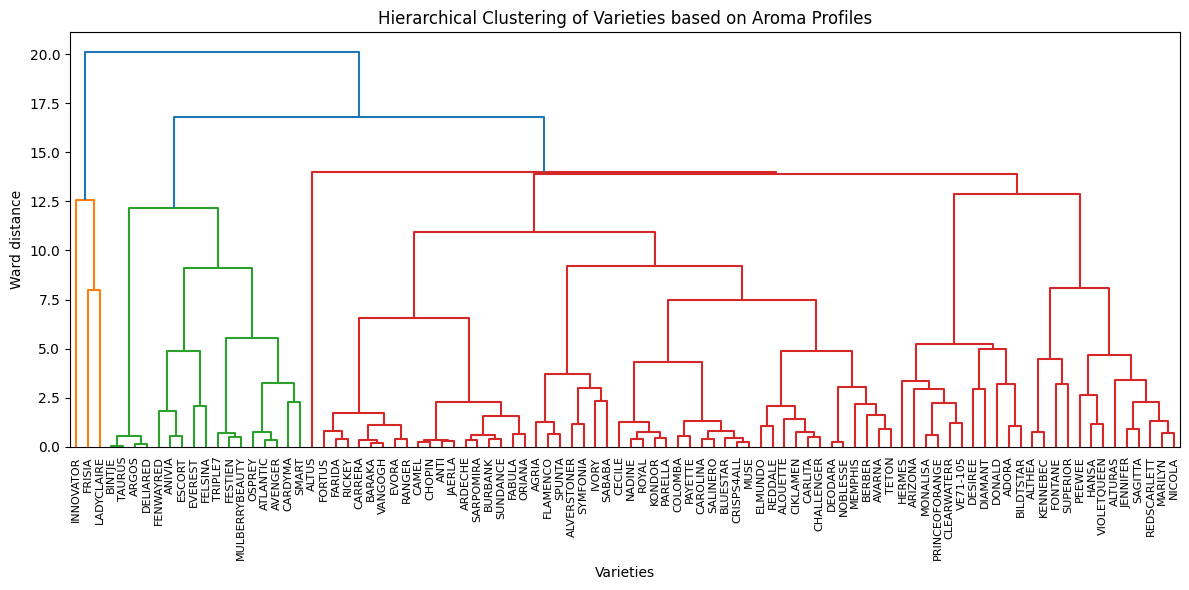

In [ ]:

merged_snp_aroma= merged_snp_aroma.copy()

# use the same aroma list
AROMA_COLS = [c for c in aroma_names if c in merged_snp_aroma.columns]

X = merged_snp_aroma[AROMA_COLS].copy().fillna(0.0)

# scale columns so compounds contribute equally
Xz = pd.DataFrame(StandardScaler().fit_transform(X.values),
                  index=X.index, columns=AROMA_COLS)

Z = linkage(Xz, method="ward", metric="euclidean")

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=X.index.tolist(), leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering of Varieties based on Aroma Profiles")
plt.xlabel("Varieties"); plt.ylabel("Ward distance")
plt.tight_layout(); plt.show()


Most varieties clustered into two major groups with several smaller subgroups, while a few varieties ( Innovator, Frisia, Lady Claire) appeared as outliers

#Select Kbestt using silhouette score

In [ ]:

# Evaluate k
k_range = range(2, 11)
sil, ch, db = [], [], []
D = pdist(Xz, metric="euclidean")
for k in k_range:
    labs = fcluster(Z, k, criterion="maxclust")
    sil.append(silhouette_score(Xz, labs))
    ch.append(calinski_harabasz_score(Xz, labs))
    db.append(davies_bouldin_score(Xz, labs))

# Choose best k by max silhouette 
best_k = k_range[int(np.argmax(sil))]
print("k  |  Silhouette  |  Calinski-Harabasz  |  Davies-Bouldin")
for k, si, c, d in zip(k_range, sil, ch, db):
    print(f"{k:2d} |   {si:8.3f}   |     {c:10.1f}     |     {d:6.3f}")
print(f"\nSelected k = {best_k} (by silhouette)")

# Final labels
clusters = fcluster(Z, best_k, criterion="maxclust")
merged_snp_aroma[f"AromaCluster_k{best_k}"] = clusters
print("\nCluster sizes:\n", pd.Series(clusters, index=merged_snp_aroma.index).value_counts().sort_index())


k  |  Silhouette  |  Calinski-Harabasz  |  Davies-Bouldin
 2 |      0.584   |           18.2     |      1.067
 3 |      0.235   |           17.8     |      1.503
 4 |      0.247   |           17.0     |      1.226
 5 |      0.210   |           17.5     |      1.426
 6 |      0.247   |           18.2     |      1.201
 7 |      0.249   |           19.4     |      1.048
 8 |      0.274   |           21.2     |      0.986
 9 |      0.242   |           22.9     |      1.028
10 |      0.265   |           23.7     |      0.992

Selected k = 2 (by silhouette)

Cluster sizes:
 1     3
2    91
Name: count, dtype: int64


# 2.HCA on merged_snp_sensory 

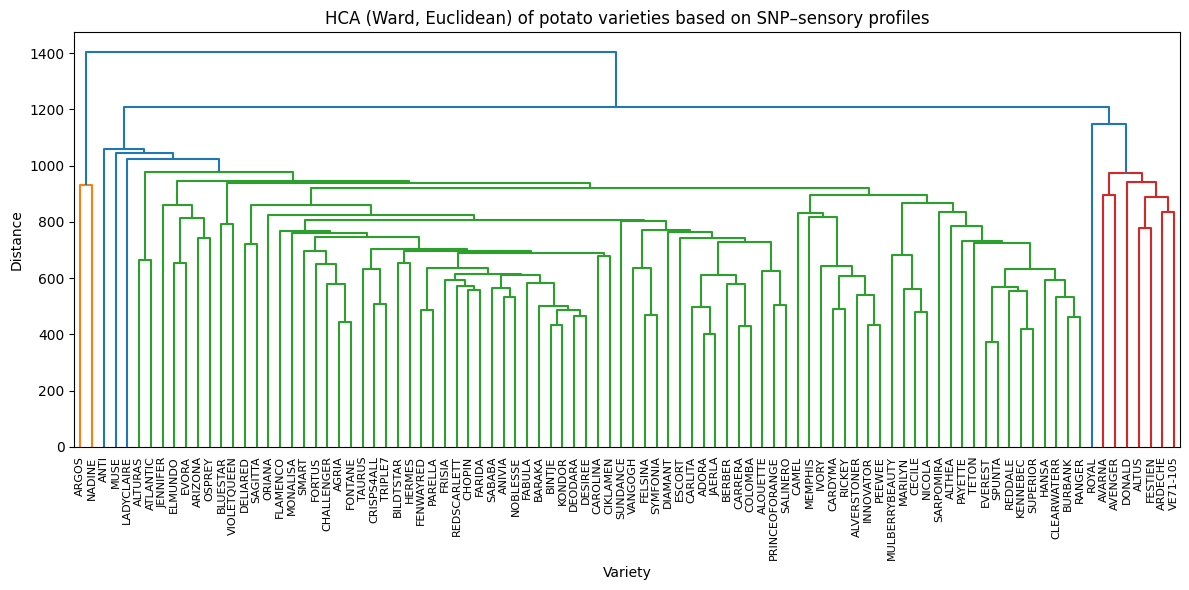

In [ ]:

# Drop non-numeric and missing columns
X = merged_snp_sensory.select_dtypes(include=[np.number]).dropna(axis=1, how="any")

# Drop rows with NaN after selection
X = X.dropna(axis=0, how="any")

# Standardize
Xz = (X - X.mean()) / X.std(ddof=0)

# Replace any inf/-inf created during scaling with NaN, then drop
Xz = Xz.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how="any")

# Compute distance + linkage
D = pdist(Xz, metric="euclidean")
Z = linkage(D, method="ward")

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=Xz.index, leaf_rotation=90, leaf_font_size=8, color_threshold=0.7*max(Z[:,2]))
plt.title("HCA (Ward, Euclidean) of potato varieties based on SNP–sensory profiles")
plt.xlabel("Variety")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


Hierarchical clustering of the SNP–sensory dataset grouped the potato varieties into several distinct clusters. Two larger clusters were observed alongside smaller subgroups, with a few varieties separating as clear outliers(Nadin, Argos). This indicates that genetic variation partly explains sensory differences, and some varieties have unique sensory-linked SNP profiles.

In [ ]:

# Evaluate k
k_range = range(2, 11)
sil, ch, db = [], [], []
D = pdist(Xz, metric="euclidean")
for k in k_range:
    labs = fcluster(Z, k, criterion="maxclust")
    sil.append(silhouette_score(Xz, labs))
    ch.append(calinski_harabasz_score(Xz, labs))
    db.append(davies_bouldin_score(Xz, labs))

# Choose best k by max silhouette 
best_k = k_range[int(np.argmax(sil))]
print("k  |  Silhouette  |  Calinski-Harabasz  |  Davies-Bouldin")
for k, si, c, d in zip(k_range, sil, ch, db):
    print(f"{k:2d} |   {si:8.3f}   |     {c:10.1f}     |     {d:6.3f}")
print(f"\nSelected k = {best_k} (by silhouette)")

# Final labels
clusters = fcluster(Z, best_k, criterion="maxclust")
merged_snp_sensory[f"AromaCluster_k{best_k}"] = clusters
print("\nCluster sizes:\n", pd.Series(clusters, index=merged_snp_sensory.index).value_counts().sort_index())


k  |  Silhouette  |  Calinski-Harabasz  |  Davies-Bouldin
 2 |      0.280   |            3.8     |      1.347
 3 |      0.167   |            3.4     |      2.756
 4 |      0.154   |            3.2     |      2.111
 5 |      0.155   |            3.0     |      1.827
 6 |      0.157   |            2.9     |      1.638
 7 |      0.157   |            2.8     |      1.505
 8 |      0.103   |            2.7     |      1.515
 9 |      0.105   |            2.7     |      1.425
10 |      0.088   |            2.6     |      1.609

Selected k = 2 (by silhouette)

Cluster sizes:
 1     2
2    92
Name: count, dtype: int64


the clusters are imbalance it probably beacuse of outiers so we will check the outliers.

During clustering, a few varieties appeared as outliers in both SNP–aroma and SNP–sensory datasets. Because these outliers strongly affected model performance, they were excluded from training to improve prediction accuracy. They are reported separately as varieties with distinct profiles.

# Feature engineering

SNPs: cleaned, normalized variety names, and reduced dimensionality with PCA.

Aroma: kept relevant compounds, removed constants, log-transformed, standardized, and extracted PCs.

Sensory: imported panel PCA scores, normalized names, kept numeric PCs.

Merging: built separate datasets (SNP + aroma, SNP + sensory, SNP + aroma + sensory) for different prediction tasks.

#  Feature selection and preprocessing

# 1. PCA on aroma and Snps

PCA was applied separately to SNPs and traits. For SNPs, dimensionality reduction was needed due to the very high number of markers, while for traits PCA helped summarize correlated variables into a few independent components.

SNP PCA → reduced 262,434 SNPs → 30 PCs kept (61% variance explained)
Aroma PCA → 3 PCs kept (64% variance explained)

# 2. MAF filter 

SNPs were filtered using a MAF threshold to exclude rare alleles before association testing

Total SNPs before filtering: 262434
SNPs kept after MAF > 0.05: 58978
Original dataset: (94, 262448)
After MAF filter: (94, 58992)


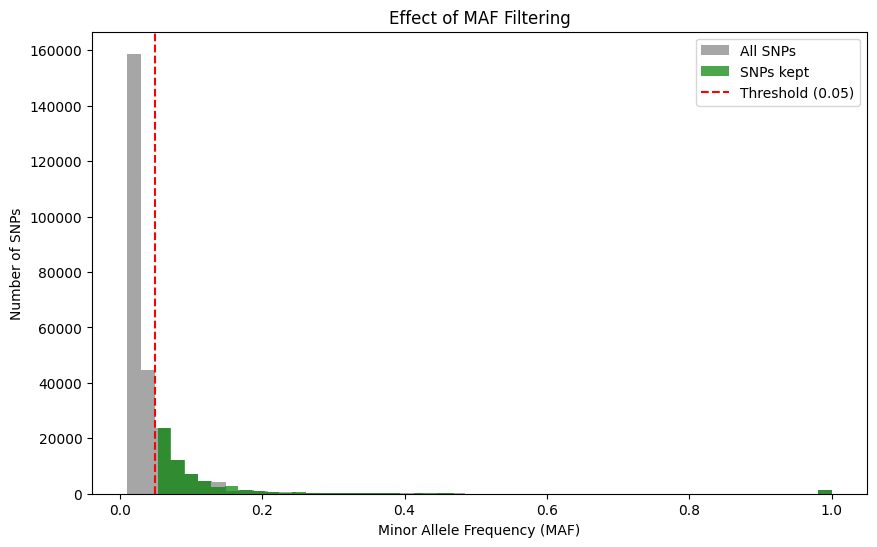

In [ ]:
# Identify SNP columns
snp_cols = [c for c in merged_snp_aroma.columns if c.startswith("GEN__")]
print(f"Total SNPs before filtering: {len(snp_cols)}")

# Compute MAF
maf = merged_snp_aroma[snp_cols].apply(
    lambda x: x.value_counts(normalize=True).min(), axis=0
)
# Apply filter (keep SNPs with MAF > 0.05)
snp_keep = maf[maf > 0.05].index.tolist()
print(f"SNPs kept after MAF > 0.05: {len(snp_keep)}")

# Filter dataset
merged_maf = merged_snp_aroma[snp_keep + [c for c in merged_snp_aroma.columns if not c.startswith("GEN__")]]

# Quick summary
print("Original dataset:", merged_snp_aroma.shape)
print("After MAF filter:", merged_maf.shape)

# Plot MAF distribution
plt.figure(figsize=(10,6))
plt.hist(maf.values, bins=50, alpha=0.7, color="gray", label="All SNPs")
plt.hist(maf[snp_keep].values, bins=50, alpha=0.7, color="green", label="SNPs kept")
plt.axvline(0.05, color="red", linestyle="--", label="Threshold (0.05)")
plt.xlabel("Minor Allele Frequency (MAF)")
plt.ylabel("Number of SNPs")
plt.title("Effect of MAF Filtering")
plt.legend()
plt.show()

# 3. ANOVA 

The results for visualization was related to hexanal and pc1 as traits

In [ ]:
from sklearn.feature_selection import f_regression

# SNPs
X = merged_snp_aroma[[c for c in merged_snp_aroma.columns if c.startswith("GEN__")]]
# One aroma trait (you can loop over traits)
y = merged_snp_aroma["Hexanal (Green, grassy)"]

# Run ANOVA F-test
f_vals, p_vals = f_regression(X.fillna(0), y)

# Build result table
anova_res = pd.DataFrame({
    "SNP": X.columns,
    "F_value": f_vals,
    "p_value": p_vals
}).sort_values("p_value")

print(anova_res.head(10))   # show top 10 SNPs


                SNP    F_value   p_value
230866  GEN__498864  15.335145  0.000173
230867  GEN__498865  14.958255  0.000205
231033  GEN__499144  14.811952  0.000219
230822  GEN__498785  14.461555  0.000257
103688  GEN__220728  14.306017  0.000276
231050  GEN__499171  14.118227  0.000301
231032  GEN__499143  13.581336  0.000386
141829  GEN__304346  13.385848  0.000422
230649  GEN__498516  13.111728  0.000480
184414  GEN__390464  13.014838  0.000502


In [ ]:
from sklearn.feature_selection import f_regression
import pandas as pd

# SNPs
X = merged_snp_sensory[[c for c in merged_snp_sensory.columns if c.startswith("GEN__")]]
# One aroma trait (you can loop over traits)
y = merged_snp_sensory["PC1"]

# Run ANOVA F-test
f_vals, p_vals = f_regression(X.fillna(0), y)

# Build result table
anova_pc1 = pd.DataFrame({
    "SNP": X.columns,
    "F_value": f_vals,
    "p_value": p_vals
}).sort_values("p_value")

print(anova_pc1.head(10))   # show top 10 SNPs


                SNP    F_value       p_value
223014  GEN__484494  40.156228  8.545228e-09
221636  GEN__481597  40.156228  8.545228e-09
141037  GEN__303064  40.156228  8.545228e-09
208075  GEN__439438  40.156228  8.545228e-09
234104  GEN__504579  40.156228  8.545228e-09
75310   GEN__160530  35.824176  4.111165e-08
75291   GEN__160496  35.824176  4.111165e-08
75236   GEN__160415  35.824176  4.111165e-08
75335   GEN__160568  35.824176  4.111165e-08
75380   GEN__160644  35.824176  4.111165e-08


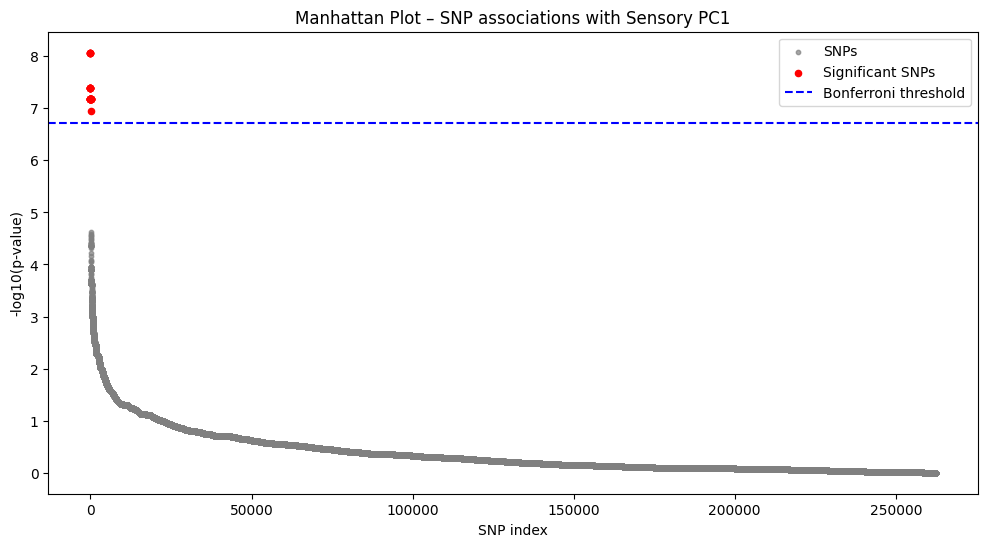

In [ ]:

# Sort by SNP index (just to give them an order for plotting)
anova_pc1 = anova_pc1.reset_index(drop=True)

# Convert p-values to -log10 scale
anova_pc1["minus_log10_p"] = -np.log10(anova_pc1["p_value"])

# Manhattan-style plot
plt.figure(figsize=(12,6))
plt.scatter(anova_pc1.index, anova_pc1["minus_log10_p"], 
            c="gray", s=10, alpha=0.7, label="SNPs")

# Highlight genome-wide significant SNPs (p < 1e-5 for example)
sig_hits = anova_pc1[anova_pc1["p_value"] < 1e-5]
plt.scatter(sig_hits.index, sig_hits["minus_log10_p"], 
            c="red", s=20, label="Significant SNPs")

# Threshold line (Bonferroni or arbitrary)
threshold = -np.log10(0.05 / len(anova_pc1))  # Bonferroni
plt.axhline(threshold, color="blue", linestyle="--", label="Bonferroni threshold")

plt.xlabel("SNP index")
plt.ylabel("-log10(p-value)")
plt.title("Manhattan Plot – SNP associations with Sensory PC1")
plt.legend()
plt.show()


# 4. GWAS-like scan

correlation-based test across all SNPs with FDR correction, capturing associations at genome-wide scale.

In [9]:

# Copy dataset
df = merged_snp_aroma.copy()

# SNP columns
snp_cols = [c for c in df.columns if c.startswith("GEN__")]

# Aroma trait example (Hexanal)
y = np.log1p(df["Hexanal (Green, grassy)"].astype(float).clip(lower=0)).values

# Filter SNPs by MAF > 0.05
maf = df[snp_cols].apply(lambda x: x.value_counts(normalize=True).min(), axis=0)
snp_keep = maf[maf > 0.05].index.tolist()
print(f"[filter] Kept {len(snp_keep)} SNPs (from {len(snp_cols)}) after MAF > 0.05")

# SNP matrix
G = df[snp_keep].fillna(df[snp_keep].mode().iloc[0]).astype(float).values

# Standardize
y = (y - y.mean()) / (y.std() if y.std() != 0 else 1)
G = (G - G.mean(axis=0)) / (G.std(axis=0, ddof=0) + 1e-6)

n = G.shape[0]

# Correlation-based GWAS
r = np.dot(y, G) / (n - 1)
r = np.clip(r, -1, 1)

# t-statistic and p-values
t = r * np.sqrt((n - 2) / (1 - r**2))
pvals = 2 * tdist.sf(np.abs(t), df=n - 2)

res_df = pd.DataFrame({
    "SNP": snp_keep,
    "r": r,
    "p": pvals
})

# FDR correction
res_df["p_fdr"] = multipletests(res_df["p"], method="fdr_bh")[1]

# Sort and show top hits
top_hits = res_df.sort_values("p_fdr").head(10)
print(top_hits)


[filter] Kept 58978 SNPs (from 262434) after MAF > 0.05
               SNP         r         p     p_fdr
47658  GEN__440822  0.265175  0.009795  0.898203
51629  GEN__498645 -0.265582  0.009679  0.898203
5104    GEN__49839  0.262814  0.010493  0.898203
3762    GEN__38446  0.262814  0.010493  0.898203
3771    GEN__38500  0.262814  0.010493  0.898203
3671    GEN__37467  0.262814  0.010493  0.898203
51612  GEN__498547 -0.265582  0.009679  0.898203
3809    GEN__38972  0.262814  0.010493  0.898203
44134  GEN__408889  0.262814  0.010493  0.898203
5149    GEN__50128  0.262814  0.010493  0.898203


Multi-trait / multivariate association

In [ ]:


df = merged_snp_aroma.copy()

# SNPs
snp_cols = [c for c in df.columns if c.startswith("GEN__")]

# Aroma traits (all compounds you kept)
aroma_cols = [
    '1-Nonanol (Floral, waxy)',
    '2,3-Butanedione (Butter, creamy, sweet)',
    'Benzaldehyde (Almond, cherry, fruity)',
    'Butanal, 3-methyl- (Fruity, malty, chocolate)',
    'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)',
    'Decanal (Citrus, floral)',
    'Dimethyl trisulfide (Garlic, onion, sulfurous)',
    'Furfural (Sweet, almond, caramel)',
    'Hexanal (Green, grassy)',
    'Hexanoic acid (Fatty, cheesy, sweaty)',
    'Methional (Cooked potato, sulfurous)',
    'Octanal (Citrus, fruity)',
    'Pentanal (Green, fatty, pungent)',
]
Y = df[aroma_cols].astype(float).fillna(0).values
n, p = Y.shape  # n = samples, p = traits

# Standardize Y
Y = (Y - Y.mean(axis=0)) / (Y.std(axis=0, ddof=0) + 1e-6)

# MAF filter 
maf = df[snp_cols].apply(lambda x: x.value_counts(normalize=True).min(), axis=0)
snp_keep = maf[maf > 0.05].index.tolist()
print(f"[filter] Kept {len(snp_keep)} SNPs (from {len(snp_cols)}) after MAF > 0.05")

# Multi-trait association (similar to MANOVA) 
results = []
for snp in snp_keep[:2000]:  # limit for speed (adjust/remove in full run)
    x = df[snp].fillna(df[snp].mode().iloc[0]).astype(float).values
    x = (x - x.mean()) / (x.std() + 1e-6)

    # Correlation with all traits
    r_vec = np.dot(x, Y) / (n - 1)  # correlation for each trait
    ssq = np.sum(r_vec**2)          # sum of squared correlations

    # Approximate F-test (like Pillai’s trace)
    F_val = (ssq / p) / ((1 - ssq) / (n - p - 1))
    p_val = f.sf(F_val, p, n - p - 1)

    results.append((snp, F_val, p_val))

# Collect results
multi_df = pd.DataFrame(results, columns=["SNP", "F_value", "p_value"])

# FDR correction
multi_df["p_fdr"] = multipletests(multi_df["p_value"], method="fdr_bh")[1]

# Top SNPs
top_hits = multi_df.sort_values("p_fdr").head(10)
print(top_hits)


[filter] Kept 58978 SNPs (from 262434) after MAF > 0.05
             SNP   F_value       p_value         p_fdr
483    GEN__7103  9.270516  2.502424e-11  5.004847e-08
1218  GEN__16691  6.666294  1.910008e-08  1.910008e-05
560    GEN__8171  5.005815  2.275996e-06  4.551992e-04
553    GEN__8109  5.005815  2.275996e-06  4.551992e-04
539    GEN__7956  5.005815  2.275996e-06  4.551992e-04
568    GEN__8253  5.005815  2.275996e-06  4.551992e-04
547    GEN__8030  5.005815  2.275996e-06  4.551992e-04
522    GEN__7840  5.005815  2.275996e-06  4.551992e-04
1143  GEN__15763  5.185886  1.326020e-06  4.551992e-04
1327  GEN__18377  5.005815  2.275996e-06  4.551992e-04


Unlike single-trait GWAS (where no strong signals were detected for compounds like Hexanal), the multivariate association test identified SNPs significantly linked to variation across multiple aroma traits. This suggests that some markers may influence groups of correlated volatiles rather than individual compounds in isolation.

In [ ]:



df = merged_snp_sensory.copy()

# SNPs
snp_cols = [c for c in df.columns if c.startswith("GEN__")]

# Sensory PCs (you already have PC1–PC3)
sensory_cols = [c for c in df.columns if c.startswith("PC")]
Y = df[sensory_cols].astype(float).fillna(0).values
n, p = Y.shape  # n = samples, p = traits

# Standardize Y
Y = (Y - Y.mean(axis=0)) / (Y.std(axis=0, ddof=0) + 1e-6)

# MAF filter
maf = df[snp_cols].apply(lambda x: x.value_counts(normalize=True).min(), axis=0)
snp_keep = maf[maf > 0.05].index.tolist()
print(f"[filter] Kept {len(snp_keep)} SNPs (from {len(snp_cols)}) after MAF > 0.05")

# --- Multi-trait association (similar to MANOVA) ---
results = []
for snp in snp_keep[:2000]:  # limit for speed (remove limit for full run)
    x = df[snp].fillna(df[snp].mode().iloc[0]).astype(float).values
    x = (x - x.mean()) / (x.std() + 1e-6)

    # Correlation with all PCs
    r_vec = np.dot(x, Y) / (n - 1)
    ssq = np.sum(r_vec**2)

    # Approximate F-test
    F_val = (ssq / p) / ((1 - ssq) / (n - p - 1))
    p_val = f.sf(F_val, p, n - p - 1)

    results.append((snp, F_val, p_val))

# Collect results
multi_df_sensory = pd.DataFrame(results, columns=["SNP", "F_value", "p_value"])

# FDR correction
multi_df_sensory["p_fdr"] = multipletests(multi_df_sensory["p_value"], method="fdr_bh")[1]

# Top SNPs
top_hits_sensory = multi_df_sensory.sort_values("p_fdr").head(10)
print(top_hits_sensory)


[filter] Kept 58978 SNPs (from 262434) after MAF > 0.05
             SNP   F_value   p_value     p_fdr
580    GEN__8413  8.164733  0.000072  0.048281
581    GEN__8423  8.164733  0.000072  0.048281
1344  GEN__18557  8.164733  0.000072  0.048281
279    GEN__3781  7.260478  0.000204  0.081695
611    GEN__9130  7.281719  0.000199  0.081695
278    GEN__3780  6.661637  0.000410  0.105103
395    GEN__5892  6.743452  0.000373  0.105103
394    GEN__5890  6.640983  0.000420  0.105103
547    GEN__8030  5.614979  0.001419  0.111096
254    GEN__3523  5.976040  0.000922  0.111096


# 5. Variance thresholding

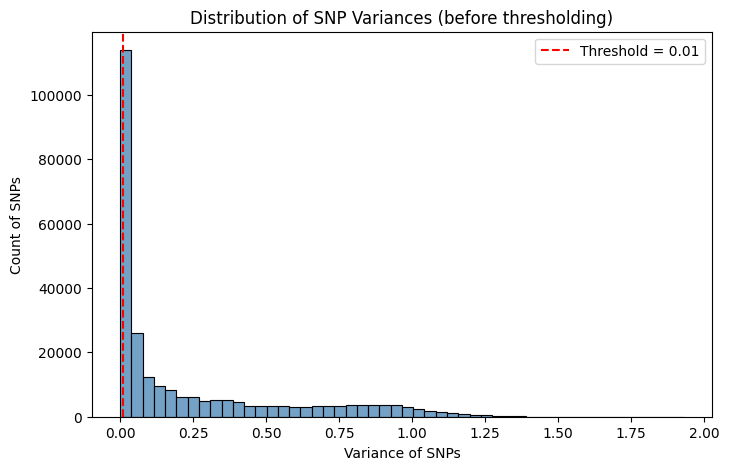

Original SNPs: 262434
Remaining SNPs after threshold: 261110


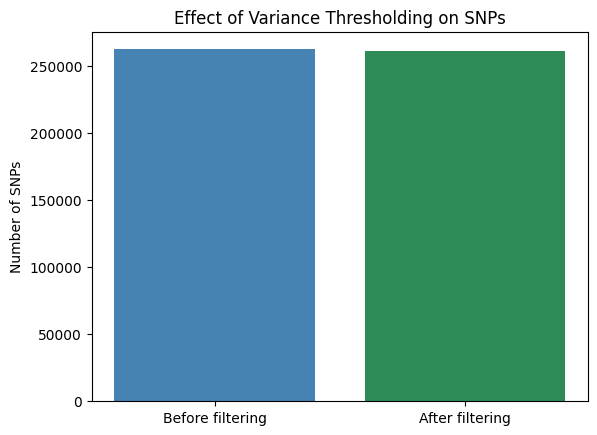

In [ ]:

# SNP-only dataset
X = merged_snp_aroma[[c for c in merged_snp_aroma.columns if c.startswith("GEN__")]].astype(float)

# Calculate variances
variances = X.var(axis=0)

# Plot distribution of SNP variances
plt.figure(figsize=(8,5))
sns.histplot(variances, bins=50, kde=False, color="steelblue")
plt.axvline(0.01, color="red", linestyle="--", label="Threshold = 0.01")
plt.xlabel("Variance of SNPs")
plt.ylabel("Count of SNPs")
plt.title("Distribution of SNP Variances (before thresholding)")
plt.legend()
plt.show()

# Apply variance threshold
selector = VarianceThreshold(threshold=0.01)
X_selected = selector.fit_transform(X)

print(f"Original SNPs: {X.shape[1]}")
print(f"Remaining SNPs after threshold: {X_selected.shape[1]}")
# Count before/after
before = X.shape[1]
after = X_selected.shape[1]

plt.bar(["Before filtering", "After filtering"], [before, after], color=["steelblue", "seagreen"])
plt.ylabel("Number of SNPs")
plt.title("Effect of Variance Thresholding on SNPs")
plt.show()


Out of 262,434 SNPs, 261,110 remained after applying a variance threshold of 0.01, removing low-variance markers that provide little discriminatory power.

# The result of testing diffrent feature selection methods
Among the feature selection approaches tested (MAF filtering, variance thresholding, ANOVA F-test, GWAS-like scan), multivariate association testing proved to be the most effective. Unlike univariate tests, it considered correlations among traits (e.g., aroma compounds, sensory PCs) simultaneously and identified SNPs with significant associations after FDR correction, making it the most suitable feature selection method for prediction modeling

# Dimensionality Reduction

Significant SNPs (FDR<0.05): 105
Selected SNP shape: (94, 105)
Reduced PCA shape: (94, 30)
Explained variance: 0.9882708156590273


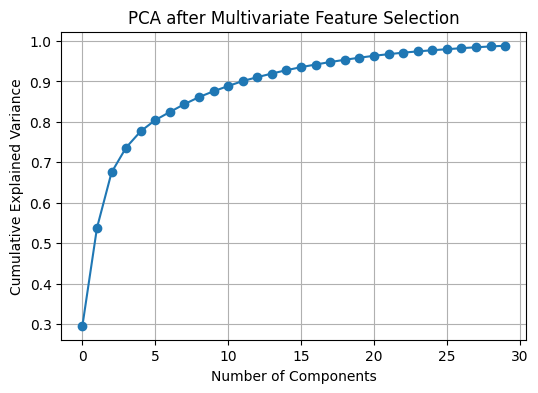

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: Keep significant SNPs from multivariate test ---
sig_snps = multi_df[multi_df["p_fdr"] < 0.05]["SNP"].tolist()
print(f"Significant SNPs (FDR<0.05): {len(sig_snps)}")

# If too few SNPs, fallback to top 500 by p-value
if len(sig_snps) < 20:
    sig_snps = multi_df.sort_values("p_value").head(500)["SNP"].tolist()
    print(f"Using top {len(sig_snps)} SNPs by p-value")

# --- Step 2: Build reduced SNP matrix from original df ---
X_selected = df[sig_snps].astype(float).fillna(0)

# --- Step 3: Standardize ---
X_scaled = StandardScaler().fit_transform(X_selected)

# --- Step 4: PCA on selected SNPs ---
pca = PCA(n_components=min(30, X_scaled.shape[1]), random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Selected SNP shape:", X_selected.shape)
print("Reduced PCA shape:", X_pca.shape)
print("Explained variance:", pca.explained_variance_ratio_.sum())

# --- Scree Plot ---
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA after Multivariate Feature Selection")
plt.grid(True)
plt.show()


The scree plot shows most of the variance is captured in the first ~10 PCs, and by 30 PCs, we retained everything.

# Predicting models

# Baseline Models

# Linear Multivariate Models

# Nonlinear Models

# Random Forest